Telescope Pupil Shape: (65536,)
Masking Pupil Shape: (65536,)
Scale 3: P2V 10.3910 rad, 1.6538 waves, defocus 20992.36 microns
Scale 4: P2V 13.8547 rad, 2.2050 waves, defocus 27989.82 microns
Scale 5: P2V 17.3184 rad, 2.7563 waves, defocus 34987.27 microns
Scale 6: P2V 20.7821 rad, 3.3076 waves, defocus 41984.73 microns
PSF 0: shape=(512, 512), max=34459.45, min=0.00
PSF 1: shape=(512, 512), max=3070.09, min=0.03
PSF 2: shape=(512, 512), max=1647.09, min=0.06
PSF 3: shape=(512, 512), max=864.29, min=0.10
PSF 4: shape=(512, 512), max=565.65, min=0.19
Iteration 0: PSF max=162.39+87.84j, min=-60.37+16.66j
Iteration 50: PSF max=104.40+150.71j, min=-39.81-63.29j
Iteration 100: PSF max=103.94+152.22j, min=-39.71-63.43j
Iteration 150: PSF max=103.31+152.65j, min=-39.33-63.59j


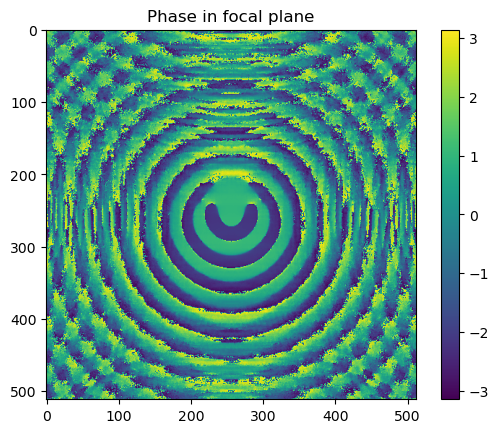

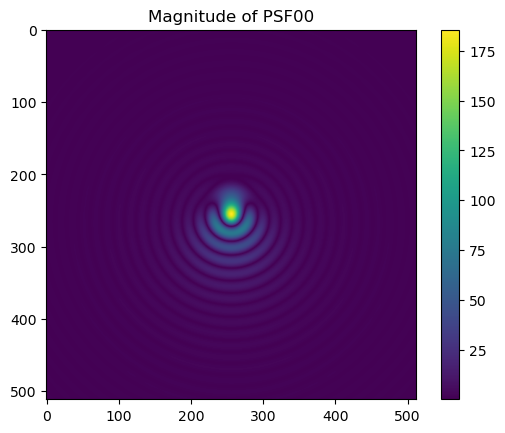

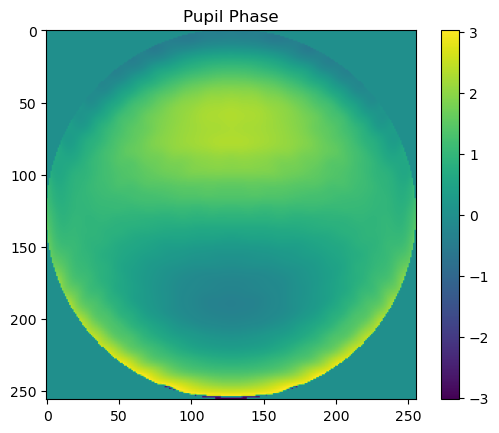

NameError: name 'pupil_phase' is not defined

In [2]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
from image_sharpening import FocusDiversePhaseRetrieval, ft_rev, mft_rev, InstrumentConfiguration
from skimage.transform import resize
from skimage.restoration import unwrap_phase
from processing import phase_unwrap_2d

# System parameters
pupil_size = 10.12e-3
small_pupil_size = 9.5e-3 
focal_length = 500e-3
wavelength = 650e-9
grid_size = 256
q = 16
num_airy = 16

# SEAL instrument configuration parameters
seal_params = {
    'image_dx': 2.0071, 
    'efl': focal_length * 1e3, # effective focal length in mm
    'wavelength': 0.65, # center wavelength in microns
    'pupil_size': pupil_size * 1e3  # entrance pupil diameter in mm
}
conf = InstrumentConfiguration(seal_params)

# Create the pupil and focal grids
pupil_grid = make_pupil_grid(grid_size, pupil_size)
focal_grid = make_focal_grid(q=q, num_airy=num_airy, pupil_diameter=pupil_size, focal_length=focal_length, reference_wavelength=wavelength)

# Aperture setup
aperture = make_circular_aperture(pupil_size)
telescope_pupil = aperture(pupil_grid)
small_aperture = make_circular_aperture(small_pupil_size)
masking_pupil = small_aperture(pupil_grid)

# Debugging: print shapes to ensure correct initialization
print(f"Telescope Pupil Shape: {telescope_pupil.shape}")
print(f"Masking Pupil Shape: {masking_pupil.shape}")

# Function to convert phase into meters using wavelength
def phase_to_m(phase, wavelength):
    return phase * wavelength / (2 * np.pi)

# Calculate defocus distance from peak-to-valley error in meters
def p_to_delta(P, f, D):
    return 8 * P * (f / D) ** 2

# Convert defocus distance into phase error
def delta_to_p(delta, f, D):
    return -delta / (8 * (f / D) ** 2)

# Function to propagate the wavefront from pupil to focal plane and return focal intensity
def propagate_image(defocus_phase, test_aberration, telescope_pupil, wavelength):
    # Setup propagator
    prop_p2f = FraunhoferPropagator(pupil_grid, focal_grid, focal_length=focal_length)
    
    # Combine test aberration and defocus phase
    combined_phase = (test_aberration + defocus_phase).ravel()
    
    # Apply phase to the telescope pupil
    pupil_field = telescope_pupil * np.exp(1j * combined_phase)
    
    # Create wavefront and propagate to focal plane
    wavefront = Wavefront(pupil_field, wavelength)
    focal_field = prop_p2f.forward(wavefront)
    
    # Calculate focal intensity
    focal_intensity = np.abs(focal_field.electric_field.reshape(focal_grid.shape)) ** 2
    return focal_intensity

# Function to calculate P2V error and defocus distance for a given defocus phase
def calculate_defocus_params(defocus_phase, scale, f, D):
    defocus_phase_scaled = defocus_phase * scale
    p2v_radians = np.max(defocus_phase_scaled) - np.min(defocus_phase_scaled)
    p2v_m = phase_to_m(p2v_radians, wavelength)
    delta = p_to_delta(p2v_m, f, D)
    delta = delta if scale > 0 else -delta
    return p2v_radians, delta

# Generate PSFs for different defocus scales and calculate associated defocus distances
def generate_defocus_lists(defocus_phase, scales, f, D, test_aberration, telescope_pupil, wavelength):
    psf_list, distance_list, dx_list = [], [], [seal_params['image_dx']] * len(scales)
    
    # Ensure shapes are compatible
    defocus_phase = defocus_phase.reshape(telescope_pupil.shape)
    test_aberration = test_aberration.reshape(telescope_pupil.shape)

    # Reference PSF without defocus
    no_defocus_image = propagate_image(np.zeros_like(defocus_phase), test_aberration, telescope_pupil, wavelength)
    psf_list.append(no_defocus_image)
    
    # Generate PSFs for each scale
    for scale in scales:
        p2v_radians, delta = calculate_defocus_params(defocus_phase, scale, f, D)
        print(f'Scale {scale}: P2V {p2v_radians:.4f} rad, {p2v_radians / (2*np.pi):.4f} waves, defocus {delta*1e6:.2f} microns')
        
        defocus_image = propagate_image(defocus_phase * scale, test_aberration, telescope_pupil, wavelength)
        psf_list.append(defocus_image)
        distance_list.append(delta * 1e6)  # in microns

    return psf_list, distance_list, dx_list

# Main function to run the focus diverse phase retrieval process
def run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale):
    # Setup Zernike polynomials for test aberrations and defocus
    zernike_basis = make_zernike_basis(grid_size, pupil_size, pupil_grid)
    test_aberration = test_ab_scale * zernike_basis[6]
    example_defocus = zernike_basis[3].shaped

    # Generate PSFs and defocus distances
    psf_list, distance_list, dx_list = generate_defocus_lists(example_defocus, scales, focal_length, pupil_size, test_aberration, telescope_pupil, wavelength)

    # Debugging: check PSF shapes and values
    for i, psf in enumerate(psf_list):
        print(f"PSF {i}: shape={psf.shape}, max={np.max(psf):.2f}, min={np.min(psf):.2f}")

    # Focus diverse phase retrieval
    mp = FocusDiversePhaseRetrieval(psf_list, 650e-3, dx_list, distance_list)
    
    for i in range(200):
        psf00 = mp.step()
        if i % 50 == 0:
            print(f"Iteration {i}: PSF max={np.max(psf00):.2f}, min={np.min(psf00):.2f}")
    
    # Plot and analyze results
    plot_phase_intensity(psf00)
    raw_pupil_phase = np.angle(mft_rev(psf00, conf))
    analyze_pupil_phase(raw_pupil_phase, telescope_pupil)

    return analyze_error(telescope_pupil, test_aberration)

# Function to plot phase and intensity
def plot_phase_intensity(psf00):
    plt.imshow(np.angle(psf00))
    plt.title('Phase in focal plane')
    plt.colorbar()
    plt.show()

    plt.imshow(np.abs(psf00))
    plt.title('Magnitude of PSF00')
    plt.colorbar()
    plt.show()

# Function to analyze and plot pupil phase
def analyze_pupil_phase(raw_pupil_phase, telescope_pupil):
    pupil_phase = resize(raw_pupil_phase, (256, 256)) * telescope_pupil.shaped
    plt.imshow(pupil_phase)
    plt.title('Pupil Phase')
    plt.colorbar()
    plt.show()

# Function to calculate errors and return key metrics
def analyze_error(telescope_pupil, test_aberration):
    med_subtracted = pupil_phase - np.median(pupil_phase[np.array(masking_pupil.shaped, dtype=bool)])
    difference_image = test_aberration - med_subtracted
    plt.imshow(difference_image * masking_pupil.shaped)
    plt.title('Difference Image * Masking Pupil')
    plt.show()

    rms_error = np.sqrt(np.mean((med_subtracted[telescope_pupil > 0] - np.mean(med_subtracted[telescope_pupil > 0])) ** 2))
    rms_nm = phase_to_m(rms_error, wavelength) * 1e9
    print(f"RMS error: {rms_nm:.2f} nm")

    return {"rms_error_nm": rms_nm, "difference_image": difference_image}
scales = [3,4,5,6]#Keep in mind larger scales will have negative impact on the phase unwrapping
test_ab_scale = 0.75
results = run_focus_diverse_phase_retrieval_v2(scales, test_ab_scale)


In [2]:
from processing import phase_unwrap_2d #make a copy and substirute for the unwrap_phase hcipy to test for larger scales